<a href="https://colab.research.google.com/github/emubarak-lamc/PosterRepo/blob/main/Projects/project_1_outline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://github.com/emubarak-lamc/PosterRepo/blob/fc1993e8fd33ed6a800c37d4ff55f3b96480ba42/Projects/project_1_outline.ipynb)

# Project 1 — Multi-Class Specimen Classification

Cytology specimens are graded into four diagnostic categories:

| Label | Meaning |
|---|---|
| `neg` | Negative — no malignancy |
| `aty` | Atypical — mildly abnormal cells |
| `sus` | Suspicious — likely malignant |
| `pos` | Positive — confirmed malignancy |

In the exploratory notebook we built these labels and examined the features. Here you will train three supervised classifiers on the same dataset and decide which generalises best to held-out specimens.

**By the end of this project you will be able to:**
- Construct a labelled feature matrix from a structured dataset
- Apply logistic regression, a support vector machine (SVM), and a random forest to a 4-class problem
- Read a confusion matrix and a classification report
- Use feature importances to understand what drives predictions
- Compare models fairly using held-out test data

In [9]:
import os

# Clone the repository to access the data file
repo_url = 'https://github.com/emubarak-lamc/PosterRepo.git'
repo_dir = 'PosterRepo'

if not os.path.exists(repo_dir):
    !git clone {repo_url}
    print(f"Repository '{repo_dir}' cloned successfully.")
else:
    print(f"Repository '{repo_dir}' already exists.")

Repository 'PosterRepo' already exists.


In [10]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

## 1. Load & Prepare Data

The pickle file stores a dictionary with one entry per category. Each entry has an `'imgs'` list and a `'metadata'` DataFrame. We only need the metadata for this project — the four numeric measurements are our features.

In [13]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
# ── Load specimens ──────────────────────────────────────────────────────────────
with open('PosterRepo/Projects/specimens_toy_data.pkl', 'rb') as f:
    data = pickle.load(f)

# Build a flat DataFrame: one row per specimen, one column per feature
frames = []
for label, contents in data.items():
    df_cat = contents['metadata'].copy()
    df_cat['target'] = label          # attach the diagnostic category as the label
    frames.append(df_cat)

df = pd.concat(frames, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)   # shuffle rows

df.head(10)

/tmp/ipykernel_6571/1108799045.py:15: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


,aty,nc_ratio,nuclear_area,cyto_area,target
0,0.730629,0.500874,19764.0,19695.0,sus
1,0.114289,0.215759,9088.0,33033.0,aty
2,0.043333,0.197442,9416.0,38274.0,aty
3,0.176669,0.448274,19482.0,23978.0,pos
4,0.178778,0.484178,21850.0,23278.0,pos
5,0.186577,0.425987,20884.0,28141.0,pos
6,0.050975,0.204481,10294.0,40048.0,neg
7,0.102967,0.389471,19657.0,30814.0,sus
8,0.074549,0.218542,10808.0,38647.0,neg
9,0.057022,0.141928,7221.0,43657.0,neg


In [14]:
# Confirm equal class balance — important for fair evaluation
df['target'].value_counts()

,count
target,
sus,25
aty,25
pos,25
neg,25


## 2. Exploratory Data Analysis

Before fitting any model it is worth asking: *do the four classes actually separate in feature space?* A pairplot shows every pair of features at once, with points coloured by class.

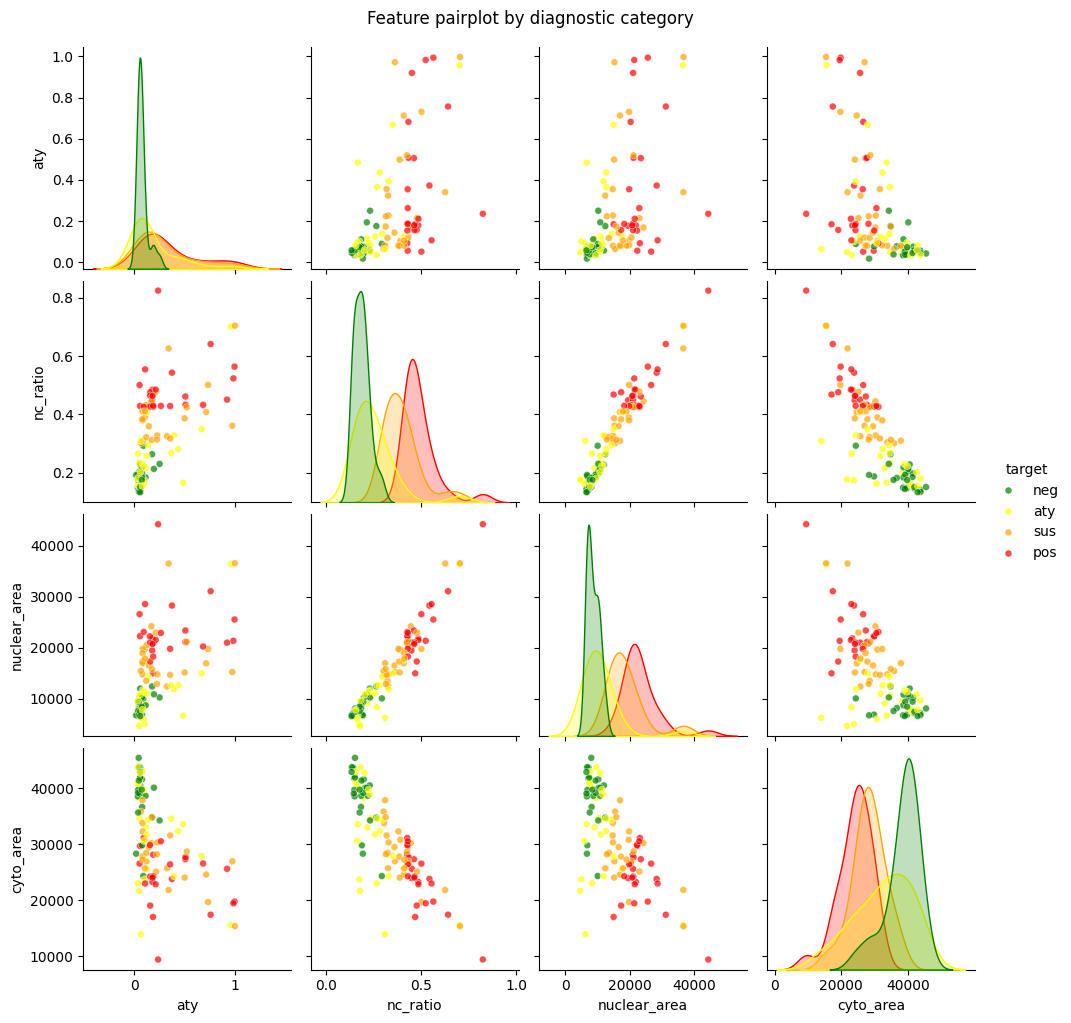

In [15]:
FEATURES = ['aty', 'nc_ratio', 'nuclear_area', 'cyto_area']

# Define a custom color palette for the target categories
custom_palette = {'neg': 'green', 'aty': 'yellow', 'sus': 'orange', 'pos': 'red'}

g = sns.pairplot(df, hue='target', vars=FEATURES,
                 plot_kws=dict(alpha=0.7, s=25),
                 hue_order=['neg', 'aty', 'sus', 'pos'],
                 palette=custom_palette) # Apply the custom palette
g.figure.suptitle('Feature pairplot by diagnostic category', y=1.02)
plt.show()

**What to look for:** `neg` clusters at low `nc_ratio` and low `aty`; `pos` sits at high values of both. `aty` and `sus` occupy the middle ground and overlap somewhat — these are the hardest cases for any classifier.

Note that `nuclear_area` and `cyto_area` are measured in pixels and are two or three orders of magnitude larger than `aty` and `nc_ratio`. Before passing features to a distance-sensitive model (logistic regression, SVM) we need to rescale them to the same range.

## 3. Feature Matrix & Train / Test Split

We separate the data into a training set (80 %) and a held-out test set (20 %). All three models will be evaluated on the *same* test set so the comparison is fair.

`StandardScaler` standardises each feature to zero mean and unit variance — essential for logistic regression and SVM, harmless for random forest.

In [16]:
# ── Feature matrix and labels ──────────────────────────────────────────────────
X = df[FEATURES].values
y = df['target'].values

# stratify=y keeps the class ratio the same in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Scale features ─────────────────────────────────────────────────────────────
# Fit the scaler on training data only — never on test data
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}   Test: {X_test_s.shape}')

Train: (80, 4)   Test: (20, 4)


## 4. Logistic Regression

Logistic regression is the simplest probabilistic linear classifier. In the multi-class setting sklearn uses a one-vs-rest strategy by default: it trains one binary classifier per class and picks the one with the highest confidence. It serves as our **baseline** — a model every other method should beat.

In [ ]:
# ── Train ──────────────────────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

# ── Evaluate ───────────────────────────────────────────────────────────────────
y_pred_lr = lr.predict(X_test_s)
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.2f}\n')
print(classification_report(y_test, y_pred_lr,
                             target_names=['neg', 'aty', 'sus', 'pos']))

In [ ]:
# ── Confusion matrix ───────────────────────────────────────────────────────────
ORDER = ['neg', 'aty', 'sus', 'pos']   # ordered by severity
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=ORDER)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=ORDER, yticklabels=ORDER, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Logistic Regression — confusion matrix')
plt.tight_layout()
plt.show()

**Follow-up question.** `aty` was the best-classified category (F1 = 0.80). Which feature is responsible? Logistic regression stores one weight per feature per class in `lr.coef_`. Because we standardised the features before training, those weights are on the same scale and can be compared directly — a larger positive weight means that feature pushes the model strongly toward predicting that class.

Run the cell below and look at the `aty` panel. Which feature has the largest coefficient? Does that match what the pairplot suggested?

In [ ]:
# ── Logistic regression coefficients by class ──────────────────────────────────
# lr.coef_ shape: (n_classes, n_features) — one row per class
# Standardised features → coefficients are directly comparable in magnitude
# Positive = pushes toward this class; negative = pushes away

fig, axes = plt.subplots(1, 4, figsize=(13, 3), sharey=True)
for ax, cls, coefs in zip(axes, lr.classes_, lr.coef_):
    colors = ['steelblue' if c >= 0 else 'tomato' for c in coefs]
    ax.barh(FEATURES, coefs, color=colors)
    ax.axvline(0, color='k', linewidth=0.6)
    ax.set_title(cls)
    ax.set_xlabel('Coefficient')
fig.suptitle('Logistic Regression — coefficients per class', y=1.02)
plt.tight_layout()
plt.show()

## 5. Support Vector Machine

An SVM finds the decision boundary that maximises the *margin* — the gap between the closest points of each class. With the RBF (radial basis function) kernel the SVM implicitly maps features into a higher-dimensional space where the classes may be more linearly separable.

The parameter `C` controls the trade-off between a wider margin and fewer misclassified training points. Large `C` means the model tries harder to classify every training point correctly (and may overfit).

In [ ]:
# ── Train ──────────────────────────────────────────────────────────────────────
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_s, y_train)

# ── Evaluate ───────────────────────────────────────────────────────────────────
y_pred_svm = svm.predict(X_test_s)
print(f'Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}\n')
print(classification_report(y_test, y_pred_svm,
                             target_names=['neg', 'aty', 'sus', 'pos']))

In [ ]:
ORDER = ['neg', 'aty', 'sus', 'pos']
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=ORDER)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=ORDER, yticklabels=ORDER, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('SVM (RBF) — confusion matrix')
plt.tight_layout()
plt.show()

## 6. Random Forest

A random forest trains many decision trees on random subsets of the data and features, then combines their votes. Because each tree sees different data, the ensemble is much more robust than any single tree.

An extra benefit: the forest records how much each feature reduces impurity across all its trees. This gives us **feature importances** — a direct answer to "which measurements matter most?"

In [ ]:
# ── Train (use unscaled features — tree models are scale-invariant) ─────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)   # note: X_train, not X_train_s

# ── Evaluate ───────────────────────────────────────────────────────────────────
y_pred_rf = rf.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}\n')
print(classification_report(y_test, y_pred_rf,
                             target_names=['neg', 'aty', 'sus', 'pos']))

In [ ]:
ORDER = ['neg', 'aty', 'sus', 'pos']
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=ORDER)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=ORDER, yticklabels=ORDER, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Random Forest — confusion matrix')
plt.tight_layout()
plt.show()

In [ ]:
# ── Feature importances ────────────────────────────────────────────────────────
importances = rf.feature_importances_
order = np.argsort(importances)   # sort ascending so the longest bar is on top

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh([FEATURES[i] for i in order], importances[order], color='steelblue')
ax.set_xlabel('Mean impurity decrease')
ax.set_title('Random Forest — feature importances')
plt.tight_layout()
plt.show()

## 7. Model Comparison

All three models were evaluated on the same 20 test specimens. **Accuracy** counts the fraction of correct predictions; **macro F1** averages the F1 score across all four classes equally, which is more informative when some classes are harder than others.

In [ ]:
# ── Summary table ──────────────────────────────────────────────────────────────
results = {
    'Model':         ['Logistic Regression', 'SVM (RBF)',           'Random Forest'],
    'Test Accuracy': [accuracy_score(y_test, y_pred_lr),
                      accuracy_score(y_test, y_pred_svm),
                      accuracy_score(y_test, y_pred_rf)],
    'Macro F1':      [f1_score(y_test, y_pred_lr,  average='macro'),
                      f1_score(y_test, y_pred_svm, average='macro'),
                      f1_score(y_test, y_pred_rf,  average='macro')],
}
(
    pd.DataFrame(results)
    .sort_values('Test Accuracy', ascending=False)
    .reset_index(drop=True)
    .style.format({'Test Accuracy': '{:.2f}', 'Macro F1': '{:.2f}'})
)

## 8. Project Guidelines

### Overview

In your group of 3–4 you will extend this notebook, interpret the results in a clinical context, and present your findings to the class. The goal is not just to run the code — it is to *understand* what the models are doing and what the outputs mean for a real diagnostic workflow.

---

### Division of Responsibilities

Divide the three models among group members. If you have a fourth member, they own the EDA section.

| Member | Ownership |
|---|---|
| A | Logistic Regression (Section 4) |
| B | Support Vector Machine (Section 5) |
| C | Random Forest (Section 6) |
| D *(if 4)* | Exploratory Data Analysis (Section 2) |

---

### Individual Tasks

Each member responsible for a model should complete all of the following in the notebook:

1. **Run the baseline** as written and record the accuracy and macro F1.
2. **Tune one hyperparameter** — try at least three values and add a small results table as a new markdown cell below your model's section. For guidance:
   - Logistic Regression: vary `C` (try `0.01`, `0.1`, `10`)
   - SVM: vary `C` (try `0.1`, `10`, `100`) or `kernel` (`'linear'`, `'poly'`, `'rbf'`)
   - Random Forest: vary `n_estimators` (try `10`, `50`, `200`)
3. **Identify the weakest class** — look at your confusion matrix and classification report, note which diagnostic category your model handles worst, and write one sentence explaining why that might be.

---

### Group Analysis

After each member completes their individual tasks, work together to answer the following in a new markdown cell at the end of the notebook:

1. Fill in the comparison table (Section 7) with your best results for each model. Which model wins on accuracy? On macro F1? Do they agree?
2. Across all three confusion matrices, which diagnostic category is most frequently misclassified? What are the clinical consequences of that error (false negative vs. false positive)?
3. The random forest feature importance plot tells you which measurements drive predictions. Does this match what the pairplot in Section 2 suggested?
4. The test set contains only 20 specimens. How much do you trust the comparison? What would you do differently with a larger dataset?

---

### Deliverable

Submit your completed notebook (all cells run, outputs visible) and prepare a **5-minute group presentation** covering:

- Your best-performing model and the evidence for choosing it
- The most common misclassification and why it matters clinically
- One concrete improvement you would make with more data or more time

---

**Wrap-up.** All three classifiers learn from the same four clinical measurements. Logistic regression draws linear decision boundaries — fast and interpretable but limited. The RBF SVM can capture curved boundaries without you having to engineer new features. Random forest builds an ensemble of trees, naturally handles feature interactions, and provides feature importances at no extra cost. Which to choose in practice depends on dataset size, interpretability requirements, and tuning budget.